# Customer Churn Prediction

## CodSoft Machine Learning Internship

### Objective
The objective of this project is to develop a Machine Learning model
that predicts whether a customer is likely to churn based on historical
customer information.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [3]:
df = pd.read_csv("Churn_Modelling.csv")
df.tail()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
9995,9996,15606229,Obijiaku,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,9997,15569892,Johnstone,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,9998,15584532,Liu,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,9999,15682355,Sabbatini,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1
9999,10000,15628319,Walker,792,France,Female,28,4,130142.79,1,1,0,38190.78,0


In [4]:
df.shape

(10000, 14)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  str    
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  str    
 5   Gender           10000 non-null  str    
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), str(3)
memory usage: 1.2 MB


In [6]:
df.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [7]:
df.columns 

Index(['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography',
       'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited'],
      dtype='str')

In [8]:
df["Exited"].value_counts()

Exited
0    7963
1    2037
Name: count, dtype: int64

In [9]:
df["Exited"].value_counts(normalize=True) * 100

Exited
0    79.63
1    20.37
Name: proportion, dtype: float64

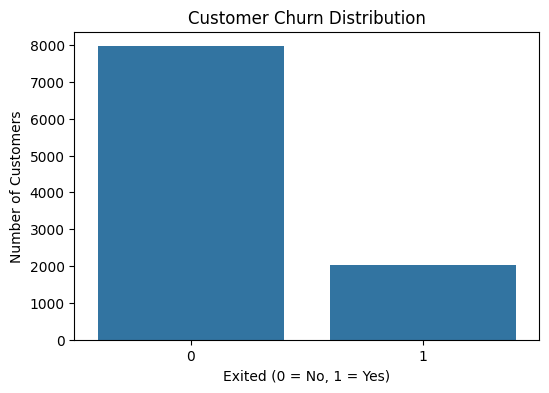

In [10]:
plt.figure(figsize=(6,4))
sns.countplot(x='Exited', data=df)

plt.title('Customer Churn Distribution')
plt.xlabel('Exited (0 = No, 1 = Yes)')
plt.ylabel('Number of Customers')
plt.show()

In [11]:
df['Exited'].value_counts()

Exited
0    7963
1    2037
Name: count, dtype: int64

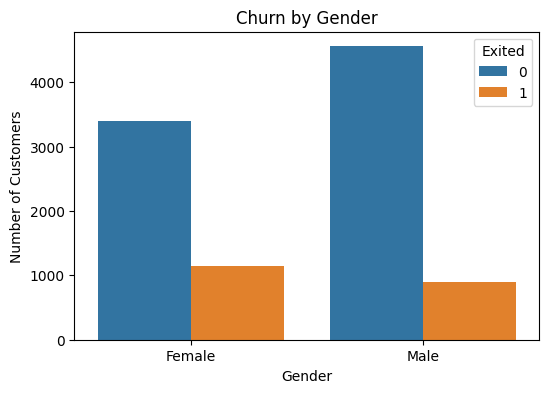

In [12]:
plt.figure(figsize=(6,4))
sns.countplot(x='Gender', hue='Exited', data=df)

plt.title('Churn by Gender')
plt.xlabel('Gender')
plt.ylabel('Number of Customers')
plt.show()

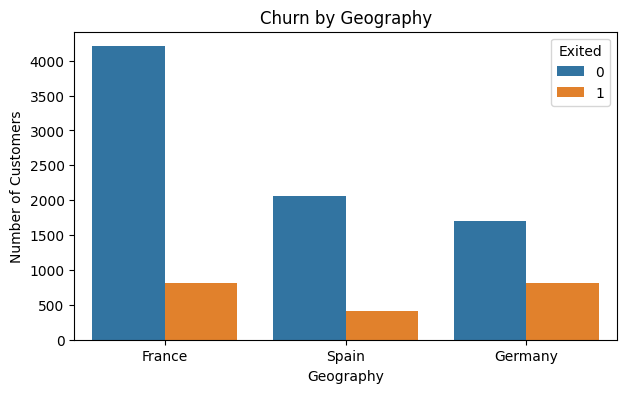

In [13]:
plt.figure(figsize=(7,4))
sns.countplot(x='Geography', hue='Exited', data=df)

plt.title('Churn by Geography')
plt.xlabel('Geography')
plt.ylabel('Number of Customers')
plt.show()

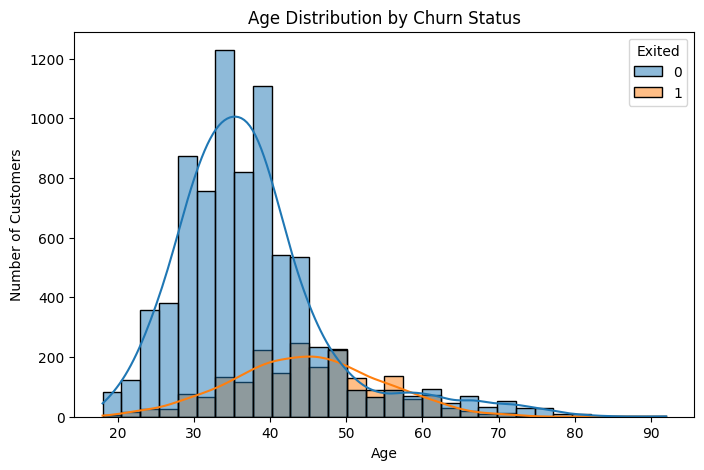

In [14]:
plt.figure(figsize=(8,5))
sns.histplot(data=df, x='Age', hue='Exited', bins=30, kde=True)

plt.title('Age Distribution by Churn Status')
plt.xlabel('Age')
plt.ylabel('Number of Customers')
plt.show()

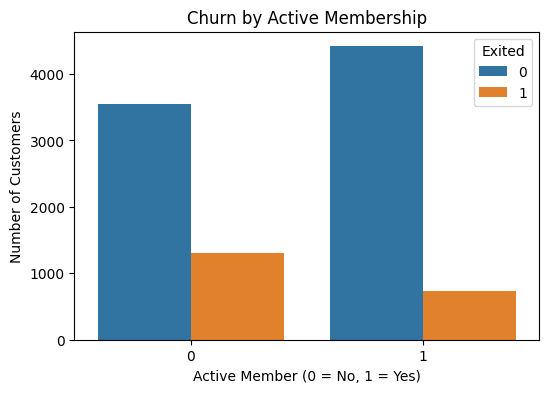

In [15]:
plt.figure(figsize=(6,4))
sns.countplot(x='IsActiveMember', hue='Exited', data=df)

plt.title('Churn by Active Membership')
plt.xlabel('Active Member (0 = No, 1 = Yes)')
plt.ylabel('Number of Customers')
plt.show()

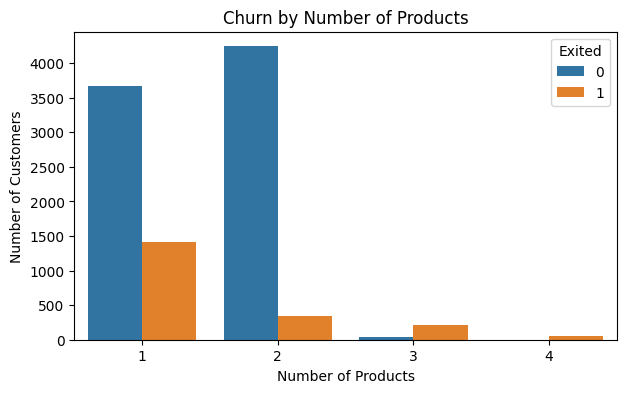

In [16]:
plt.figure(figsize=(7,4))
sns.countplot(x='NumOfProducts', hue='Exited', data=df)

plt.title('Churn by Number of Products')
plt.xlabel('Number of Products')
plt.ylabel('Number of Customers')
plt.show()

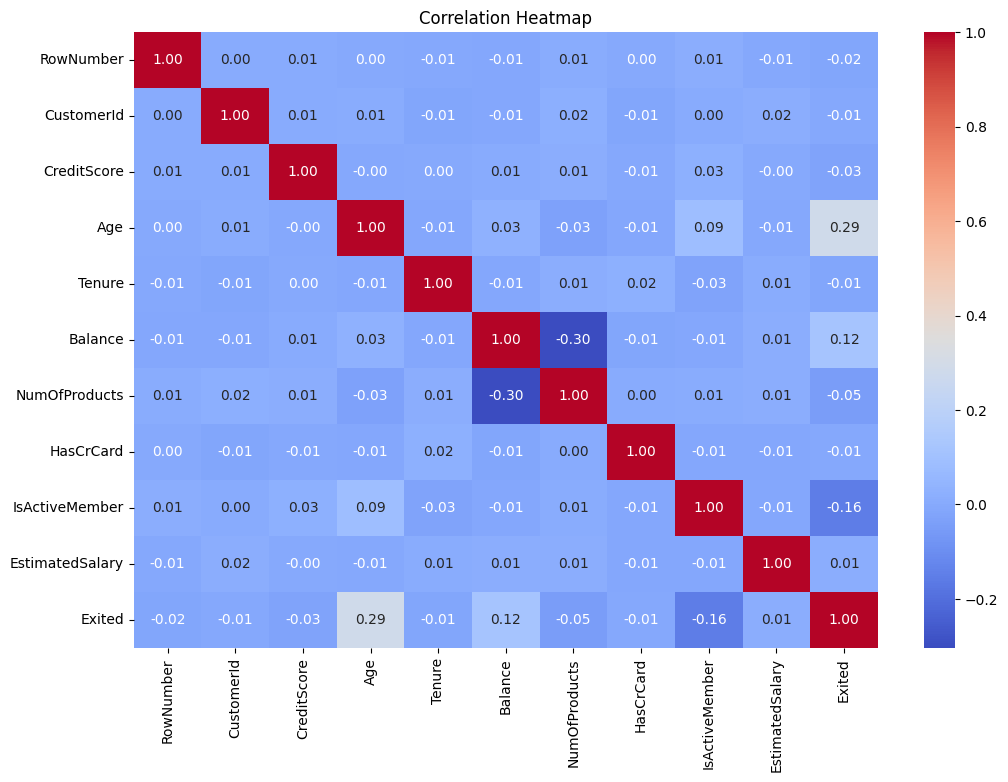

In [17]:
plt.figure(figsize=(12,8))

numeric_df = df.select_dtypes(include=np.number)

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Heatmap')
plt.show()

In [18]:
df = df.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1)

df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [19]:
X = df.drop('Exited', axis=1)
y = df['Exited']

In [20]:
X = pd.get_dummies(X, columns=['Geography', 'Gender'], drop_first=True)

X.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2,0.00,1,1,1,101348.88,False,False,False
1,608,41,1,83807.86,1,0,1,112542.58,False,True,False
2,502,42,8,159660.80,3,1,0,113931.57,False,False,False
3,699,39,1,0.00,2,0,0,93826.63,False,False,False
4,850,43,2,125510.82,1,1,1,79084.10,False,True,False


In [21]:


X.columns

Index(['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Geography_Germany',
       'Geography_Spain', 'Gender_Male'],
      dtype='str')

In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [23]:
print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (8000, 11)
Testing data: (2000, 11)


In [24]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [25]:
X_train_scaled

array([[ 1.058568  ,  1.71508648,  0.68472287, ..., -0.57831252,
        -0.57773517,  0.90750738],
       [ 0.91362605, -0.65993547, -0.6962018 , ...,  1.72916886,
        -0.57773517,  0.90750738],
       [ 1.07927399, -0.18493108, -1.73189531, ...,  1.72916886,
        -0.57773517, -1.10191942],
       ...,
       [ 0.16821031, -0.18493108,  1.3751852 , ..., -0.57831252,
        -0.57773517, -1.10191942],
       [ 0.37527024, -0.37493284,  1.02995403, ..., -0.57831252,
         1.73089688,  0.90750738],
       [ 1.56586482,  1.14508121,  0.68472287, ..., -0.57831252,
         1.73089688,  0.90750738]], shape=(8000, 11))

In [26]:
X_test_scaled

array([[-0.68073539, -0.27993196,  0.68472287, ..., -0.57831252,
        -0.57773517,  0.90750738],
       [-1.30191518, -0.5649346 , -0.35097064, ...,  1.72916886,
        -0.57773517,  0.90750738],
       [-0.97061929,  0.10007155, -0.35097064, ..., -0.57831252,
         1.73089688, -1.10191942],
       ...,
       [-1.39509214,  0.7650777 ,  1.3751852 , ...,  1.72916886,
        -0.57773517, -1.10191942],
       [ 0.39597623,  0.00507067,  0.68472287, ..., -0.57831252,
        -0.57773517,  0.90750738],
       [ 1.02750901, -0.5649346 , -1.04143297, ..., -0.57831252,
        -0.57773517,  0.90750738]], shape=(2000, 11))

# TRAIN LOGISTIC REGRESSION 

In [27]:
from sklearn.linear_model import LogisticRegression

In [28]:
logistic_model = LogisticRegression(random_state=42, max_iter=1000)

logistic_model.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [29]:
y_pred_logistic = logistic_model.predict(X_test_scaled)

In [30]:
accuracy_logistic = accuracy_score(y_test, y_pred_logistic)

print("Logistic Regression Accuracy:", accuracy_logistic)

Logistic Regression Accuracy: 0.808


In [31]:
print(classification_report(y_test, y_pred_logistic))

              precision    recall  f1-score   support

           0       0.82      0.97      0.89      1593
           1       0.59      0.19      0.28       407

    accuracy                           0.81      2000
   macro avg       0.71      0.58      0.59      2000
weighted avg       0.78      0.81      0.77      2000



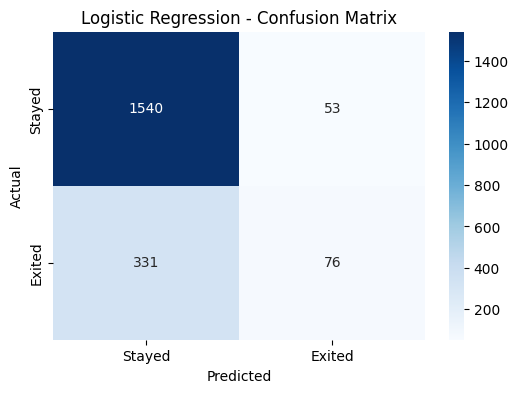

In [32]:
cm = confusion_matrix(y_test, y_pred_logistic)

plt.figure(figsize=(6,4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Stayed', 'Exited'],
    yticklabels=['Stayed', 'Exited']
)

plt.title('Logistic Regression - Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [33]:
print("Logistic Regression Accuracy:", accuracy_logistic)
print(classification_report(y_test, y_pred_logistic))

Logistic Regression Accuracy: 0.808
              precision    recall  f1-score   support

           0       0.82      0.97      0.89      1593
           1       0.59      0.19      0.28       407

    accuracy                           0.81      2000
   macro avg       0.71      0.58      0.59      2000
weighted avg       0.78      0.81      0.77      2000



# TRAIN RANDOM FOREST

In [34]:
from sklearn.ensemble import RandomForestClassifier

In [35]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [36]:
y_pred_rf = rf_model.predict(X_test)

In [37]:
accuracy_rf = accuracy_score(y_test, y_pred_rf)

print("Random Forest Accuracy:", accuracy_rf)
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.8645

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.97      0.92      1593
           1       0.78      0.46      0.58       407

    accuracy                           0.86      2000
   macro avg       0.83      0.71      0.75      2000
weighted avg       0.86      0.86      0.85      2000



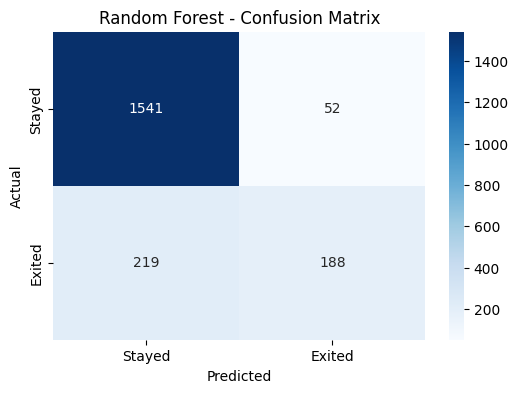

In [38]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Stayed', 'Exited'],
    yticklabels=['Stayed', 'Exited']
)

plt.title('Random Forest - Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [39]:
print("Random Forest Accuracy:", accuracy_rf)
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.8645
              precision    recall  f1-score   support

           0       0.88      0.97      0.92      1593
           1       0.78      0.46      0.58       407

    accuracy                           0.86      2000
   macro avg       0.83      0.71      0.75      2000
weighted avg       0.86      0.86      0.85      2000



# Train Gradient Boosting

In [40]:
from sklearn.ensemble import GradientBoostingClassifier

In [41]:
gb_model = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    random_state=42
)

gb_model.fit(X_train, y_train)

,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are'friedman_mse' for the mean squared error with improvement score byFriedman, 'squared_error' for mean squared error. The default value of'friedman_mse' is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, 

In [42]:
y_pred_gb = gb_model.predict(X_test)

In [43]:
accuracy_gb = accuracy_score(y_test, y_pred_gb)

print("Gradient Boosting Accuracy:", accuracy_gb)
print("\nClassification Report:")
print(classification_report(y_test, y_pred_gb))

Gradient Boosting Accuracy: 0.87

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.97      0.92      1593
           1       0.79      0.49      0.60       407

    accuracy                           0.87      2000
   macro avg       0.84      0.73      0.76      2000
weighted avg       0.86      0.87      0.86      2000



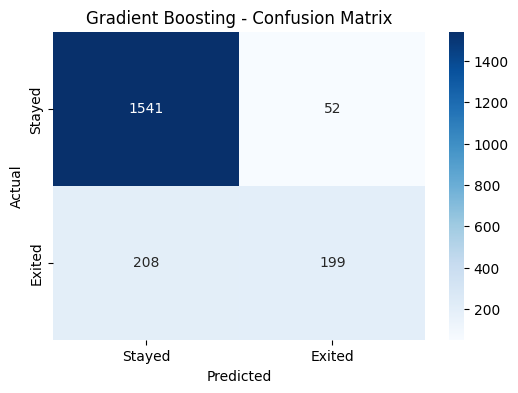

In [44]:
cm_gb = confusion_matrix(y_test, y_pred_gb)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm_gb,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Stayed', 'Exited'],
    yticklabels=['Stayed', 'Exited']
)

plt.title('Gradient Boosting - Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [45]:
accuracy_gb = accuracy_score(y_test, y_pred_gb)

print("Gradient Boosting Accuracy:", accuracy_gb)
print("\nClassification Report:")
print(classification_report(y_test, y_pred_gb))

Gradient Boosting Accuracy: 0.87

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.97      0.92      1593
           1       0.79      0.49      0.60       407

    accuracy                           0.87      2000
   macro avg       0.84      0.73      0.76      2000
weighted avg       0.86      0.87      0.86      2000



In [46]:
# Get feature importance
feature_importance = gb_model.feature_importances_

# Create a DataFrame
importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': feature_importance
})

# Sort by importance
importance_df = importance_df.sort_values(
    by='Importance',
    ascending=False
)

print(importance_df)

              Feature  Importance
1                 Age    0.388143
4       NumOfProducts    0.299886
6      IsActiveMember    0.113922
3             Balance    0.089178
8   Geography_Germany    0.055604
0         CreditScore    0.018675
7     EstimatedSalary    0.016524
10        Gender_Male    0.013160
2              Tenure    0.003759
5           HasCrCard    0.000665
9     Geography_Spain    0.000485


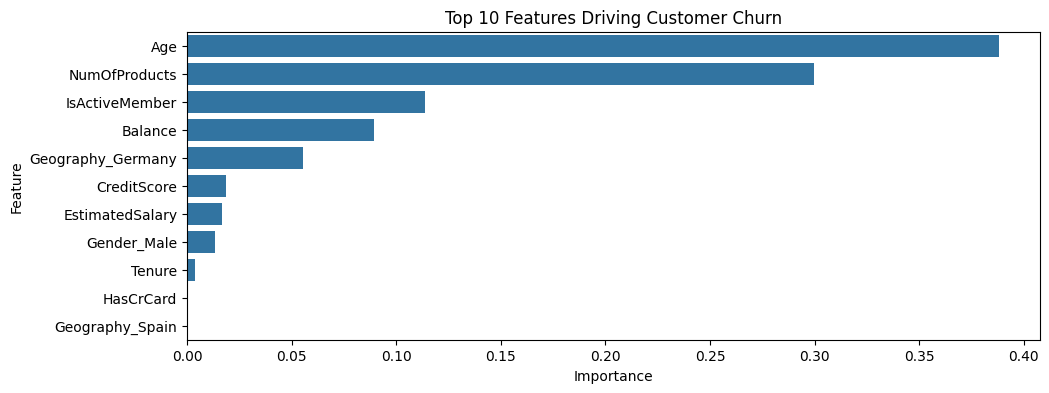

In [47]:
plt.figure(figsize=(11, 4))

sns.barplot(
    x='Importance',
    y='Feature',
    data=importance_df.head(11)
)

plt.title('Top 10 Features Driving Customer Churn')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

In [48]:
# Churn rate by number of products
print("Churn Rate by Number of Products:")
print(df.groupby('NumOfProducts')['Exited'].mean().sort_values(ascending=False))

print("\nChurn Rate by Active Membership:")
print(df.groupby('IsActiveMember')['Exited'].mean())

print("\nChurn Rate by Geography:")
print(df.groupby('Geography')['Exited'].mean())

Churn Rate by Number of Products:
NumOfProducts
4    1.000000
3    0.827068
1    0.277144
2    0.075817
Name: Exited, dtype: float64

Churn Rate by Active Membership:
IsActiveMember
0    0.268509
1    0.142691
Name: Exited, dtype: float64

Churn Rate by Geography:
Geography
France     0.161548
Germany    0.324432
Spain      0.166734
Name: Exited, dtype: float64


In [49]:
# Create age groups
df['AgeGroup'] = pd.cut(
    df['Age'],
    bins=[0, 30, 40, 50, 60, 100],
    labels=['Under 30', '30-40', '40-50', '50-60', '60+']
)

print(df.groupby('AgeGroup', observed=True)['Exited'].mean())

AgeGroup
Under 30    0.075203
30-40       0.120872
40-50       0.339655
50-60       0.562108
60+         0.247845
Name: Exited, dtype: float64


In [50]:
print("Churn Rate by Number of Products:")
print(
    df.groupby('NumOfProducts')['Exited']
      .mean()
      .sort_values(ascending=False)
)

print("\nChurn Rate by Active Membership:")
print(
    df.groupby('IsActiveMember')['Exited']
      .mean()
)

print("\nChurn Rate by Geography:")
print(
    df.groupby('Geography')['Exited']
      .mean()
)

Churn Rate by Number of Products:
NumOfProducts
4    1.000000
3    0.827068
1    0.277144
2    0.075817
Name: Exited, dtype: float64

Churn Rate by Active Membership:
IsActiveMember
0    0.268509
1    0.142691
Name: Exited, dtype: float64

Churn Rate by Geography:
Geography
France     0.161548
Germany    0.324432
Spain      0.166734
Name: Exited, dtype: float64


In [51]:
df['AgeGroup'] = pd.cut(
    df['Age'],
    bins=[0, 30, 40, 50, 60, 100],
    labels=['Under 30', '30-40', '40-50', '50-60', '60+']
)

print("\nChurn Rate by Age Group:")
print(
    df.groupby('AgeGroup', observed=True)['Exited']
      .mean()
)


Churn Rate by Age Group:
AgeGroup
Under 30    0.075203
30-40       0.120872
40-50       0.339655
50-60       0.562108
60+         0.247845
Name: Exited, dtype: float64


In [52]:
print("Churn Rate by Number of Products:")
print(
    df.groupby('NumOfProducts')['Exited']
      .mean()
      .sort_values(ascending=False)
)

print("\nChurn Rate by Active Membership:")
print(
    df.groupby('IsActiveMember')['Exited']
      .mean()
)

print("\nChurn Rate by Geography:")
print(
    df.groupby('Geography')['Exited']
      .mean()
)

Churn Rate by Number of Products:
NumOfProducts
4    1.000000
3    0.827068
1    0.277144
2    0.075817
Name: Exited, dtype: float64

Churn Rate by Active Membership:
IsActiveMember
0    0.268509
1    0.142691
Name: Exited, dtype: float64

Churn Rate by Geography:
Geography
France     0.161548
Germany    0.324432
Spain      0.166734
Name: Exited, dtype: float64


In [53]:
import pandas as pd

def predict_churn(
    credit_score,
    geography,
    gender,
    age,
    tenure,
    balance,
    num_of_products,
    has_cr_card,
    is_active_member,
    estimated_salary
):
    # Create customer data
    customer = pd.DataFrame({
        'CreditScore': [credit_score],
        'Age': [age],
        'Tenure': [tenure],
        'Balance': [balance],
        'NumOfProducts': [num_of_products],
        'HasCrCard': [has_cr_card],
        'IsActiveMember': [is_active_member],
        'EstimatedSalary': [estimated_salary],
        'Gender_Male': [1 if gender == 'Male' else 0],
        'Geography_Germany': [1 if geography == 'Germany' else 0],
        'Geography_Spain': [1 if geography == 'Spain' else 0]
    })

    # Make sure columns are in the same order as training data
    customer = customer[X_train.columns]

    # Prediction
    prediction = gb_model.predict(customer)[0]

    # Churn probability
    probability = gb_model.predict_proba(customer)[0][1]

    if prediction == 1:
        result = "Customer is likely to CHURN"
    else:
        result = "Customer is likely to STAY"

    print("Prediction:", result)
    print(f"Churn Probability: {probability * 100:.2f}%")
    print(f"Stay Probability: {(1 - probability) * 100:.2f}%")

In [54]:
predict_churn(
    credit_score=600,
    geography='Germany',
    gender='Male',
    age=52,
    tenure=3,
    balance=100000,
    num_of_products=3,
    has_cr_card=1,
    is_active_member=0,
    estimated_salary=80000
)

Prediction: Customer is likely to CHURN
Churn Probability: 95.13%
Stay Probability: 4.87%


In [55]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

# Final Gradient Boosting metrics
accuracy = accuracy_score(y_test, y_pred_gb)
precision = precision_score(y_test, y_pred_gb)
recall = recall_score(y_test, y_pred_gb)
f1 = f1_score(y_test, y_pred_gb)

# Probability predictions for ROC-AUC
y_prob_gb = gb_model.predict_proba(X_test)[:, 1]
roc_auc = roc_auc_score(y_test, y_prob_gb)

print("Final Gradient Boosting Model")
print("--------------------------------")
print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")
print(f"ROC-AUC   : {roc_auc:.4f}")

Final Gradient Boosting Model
--------------------------------
Accuracy  : 0.8700
Precision : 0.7928
Recall    : 0.4889
F1 Score  : 0.6049
ROC-AUC   : 0.8708


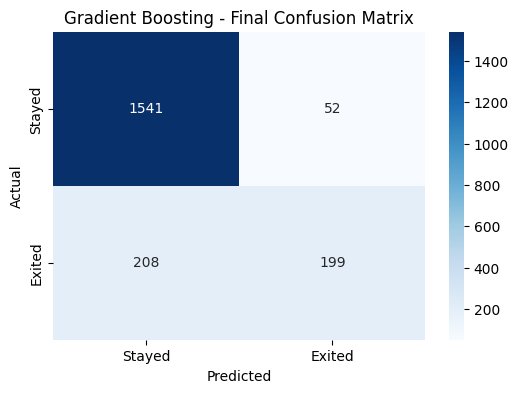

In [56]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred_gb)

plt.figure(figsize=(6, 4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Stayed', 'Exited'],
    yticklabels=['Stayed', 'Exited']
)

plt.title('Gradient Boosting - Final Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [57]:
import pandas as pd
import matplotlib.pyplot as plt

# Model comparison data
comparison = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Random Forest',
        'Gradient Boosting'
    ],
    'Accuracy': [
        0.8080,
        0.8645,
        0.8700
    ],
    'Precision': [
        0.59,
        0.78,
        0.7928
    ],
    'Recall': [
        0.19,
        0.46,
        0.4889
    ],
    'F1 Score': [
        0.28,
        0.58,
        0.6049
    ]
})

print(comparison)

                 Model  Accuracy  Precision  Recall  F1 Score
0  Logistic Regression    0.8080     0.5900  0.1900    0.2800
1        Random Forest    0.8645     0.7800  0.4600    0.5800
2    Gradient Boosting    0.8700     0.7928  0.4889    0.6049


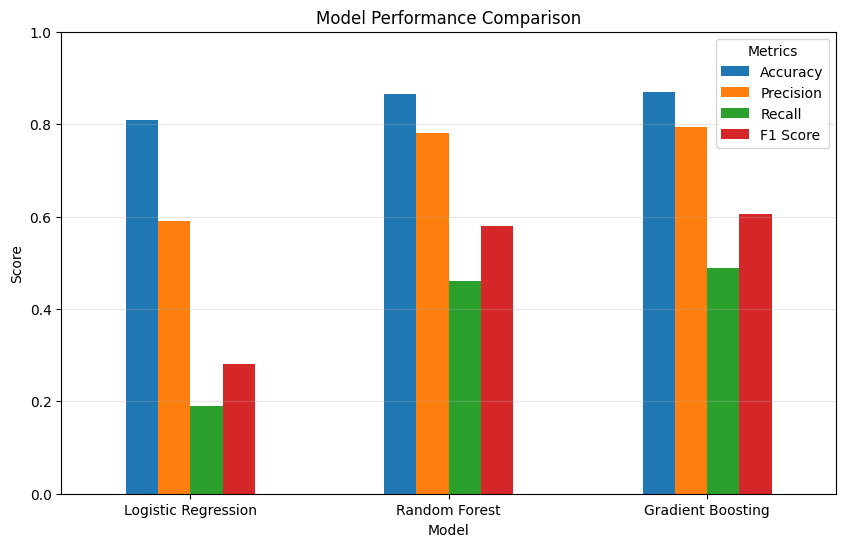

In [58]:
comparison.set_index('Model').plot(
    kind='bar',
    figsize=(10, 6)
)

plt.title('Model Performance Comparison')
plt.ylabel('Score')
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(title='Metrics')
plt.grid(axis='y', alpha=0.3)

plt.show()

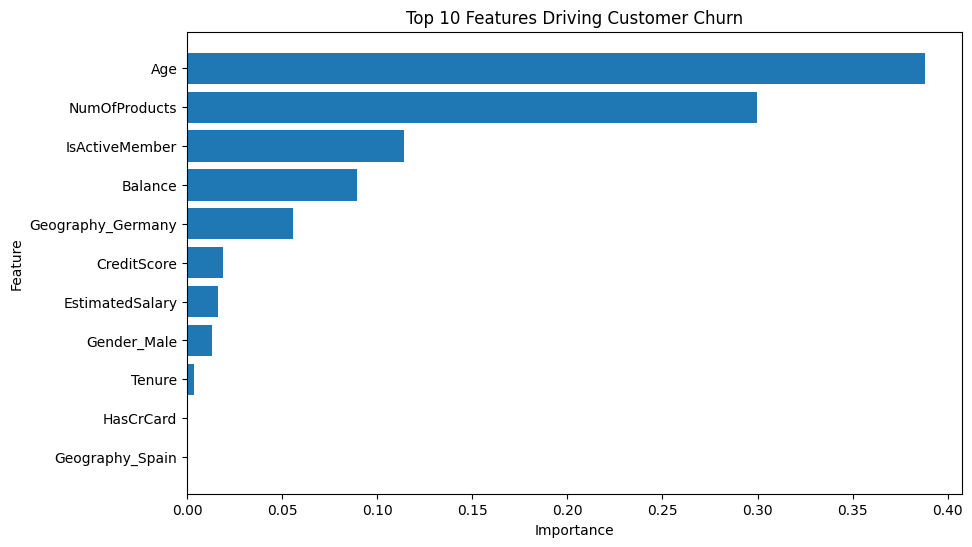

In [59]:

plt.figure(figsize=(10, 6))

plt.barh(
    importance_df['Feature'].head(11)[::-1],
    importance_df['Importance'].head(11)[::-1]
)

plt.title('Top 10 Features Driving Customer Churn')
plt.xlabel('Importance')
plt.ylabel('Feature')

plt.show()

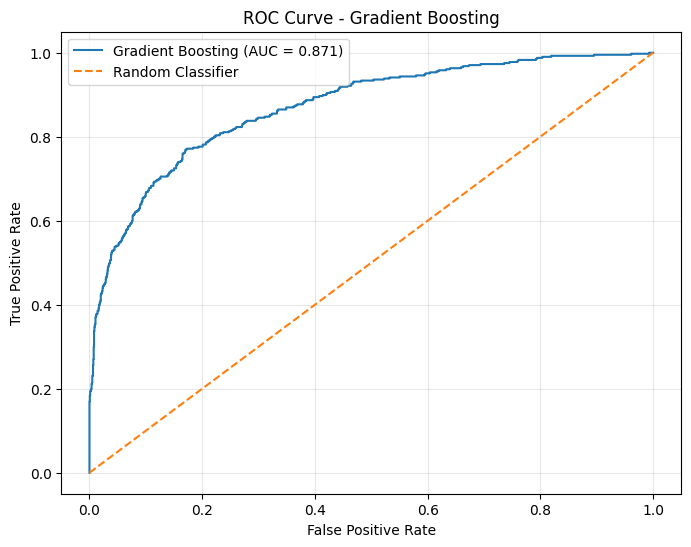

In [60]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Get probability predictions
y_prob_gb = gb_model.predict_proba(X_test)[:, 1]

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob_gb)

# Calculate AUC
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label=f'Gradient Boosting (AUC = {roc_auc:.3f})'
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle='--',
    label='Random Classifier'
)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Gradient Boosting')
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [63]:
import joblib

# Save the trained Gradient Boosting model
joblib.dump(gb_model, "gradient_boosting_model.pkl")

# Save the feature columns used during training
joblib.dump(X_train.columns.tolist(), "feature_columns.pkl")

print("Model and feature columns saved successfully!")

Model and feature columns saved successfully!


In [64]:
import joblib

# Load the saved model
loaded_model = joblib.load("gradient_boosting_model.pkl")

# Load the saved feature columns
loaded_features = joblib.load("feature_columns.pkl")

print("Model loaded successfully!")
print("Number of features:", len(loaded_features))

Model loaded successfully!
Number of features: 11


In [67]:
import pandas as pd

# Create a sample customer
sample_customer = pd.DataFrame([{
    "CreditScore": 650,
    "Geography_Germany": 0,
    "Geography_Spain": 0,
    "Gender_Male": 1,
    "Age": 40,
    "Tenure": 5,
    "Balance": 60000,
    "NumOfProducts": 2,
    "HasCrCard": 1,
    "IsActiveMember": 1,
    "EstimatedSalary": 50000
}])

# Make sure the feature order is exactly the same as training
sample_customer = sample_customer[loaded_features]

# Predict
prediction = loaded_model.predict(sample_customer)[0]
probability = loaded_model.predict_proba(sample_customer)[0][1]

if prediction == 1:
    print("Prediction: Customer is likely to CHURN")
else:
    print("Prediction: Customer is likely to STAY")

print(f"Churn Probability: {probability:.2%}")

Prediction: Customer is likely to STAY
Churn Probability: 4.57%


In [68]:
print("Features expected by the model:")
for feature in loaded_features:
    print(feature)

Features expected by the model:
CreditScore
Age
Tenure
Balance
NumOfProducts
HasCrCard
IsActiveMember
EstimatedSalary
Geography_Germany
Geography_Spain
Gender_Male
